# 題目：利用OHLCV預測股票明日漲跌
### 使用資料及來源：[kaggle](https://www.kaggle.com/datasets/mattiuzc/stock-exchange-data/data?select=indexInfo.csv)
分析流程如下：取得資料 -> 建立特徵 -> 建立 Label -> 切分訓練測試 -> 訓練 Decision Tree -> 評估模型 -> 分析規則

### 資料集介紹
indexData.csv
這是「原始股價時序資料」，每一列是某個指數某一天的行情，欄位有 Open/High/Low/Close/Adj Close/Volume。
簡單說：原始歷史價格表（跨多國指數、很多年份）。

indexProcessed.csv
這是「處理後資料」，欄位幾乎跟原始資料一樣，但多了 CloseUSD（把收盤價轉成美元後的值）。
簡單說：可跨市場比較的版本，通常用來建模或做國際市場比較更方便。

indexInfo.csv
這是「指數基本資訊對照表」，把 Index 代碼對應到 Region/Exchange/Currency。
簡單說：資料字典，幫你知道每個代碼是哪個國家、哪個交易所、什麼幣別。

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) 讀檔（先用 processed，跨市場時更好比）
df = pd.read_csv("indexProcessed.csv")

# 2) 基本清理
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Index", "Date"]).reset_index(drop=True)

# 3) 先選單一指數（建議起步）
target_index = "TWII"   # 可改成 HSI, NYA...
d = df[df["Index"] == target_index].copy()

# 4) 建立報酬與技術特徵
d["ret_1"] = d["Close"].pct_change(1)
d["ret_3"] = d["Close"].pct_change(3)
d["ret_5"] = d["Close"].pct_change(5)

d["ma_5"] = d["Close"].rolling(5).mean()
d["ma_10"] = d["Close"].rolling(10).mean()
d["ma_gap_5"] = (d["Close"] - d["ma_5"]) / d["ma_5"]
d["ma_gap_10"] = (d["Close"] - d["ma_10"]) / d["ma_10"]

d["vol_5"] = d["ret_1"].rolling(5).std()
d["hl_spread"] = (d["High"] - d["Low"]) / d["Close"]
d["oc_change"] = (d["Close"] - d["Open"]) / d["Open"]

# 5) 建立 Label：預測明天是否上漲
d["future_ret_1"] = d["Close"].shift(-1) / d["Close"] - 1
d["y"] = (d["future_ret_1"] > 0).astype(int)

# 6) 準備訓練資料
features = [
    "ret_1", "ret_3", "ret_5",
    "ma_gap_5", "ma_gap_10",
    "vol_5", "hl_spread", "oc_change"
]

model_df = d.dropna(subset=features + ["y"]).copy()

# 時間切分（例如 80% 當訓練）
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df["y"]
X_test = test_df[features]
y_test = test_df["y"]

# 7) 訓練 Decision Tree
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)
clf.fit(X_train, y_train)

# 8) 評估
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, pred))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.45      0.49      0.47       520
           1       0.56      0.51      0.53       652

    accuracy                           0.50      1172
   macro avg       0.50      0.50      0.50      1172
weighted avg       0.51      0.50      0.50      1172

=== Confusion Matrix ===
[[256 264]
 [319 333]]
ROC-AUC: 0.5189461420481358


In [2]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# 1) 時間序列交叉驗證 + 調參
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [3, 4, 5, 6, 8],
    "min_samples_leaf": [20, 50, 100, 200],
    "min_samples_split": [50, 100, 200],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_clf = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# 2) 用最佳模型在測試集評估
best_pred = best_clf.predict(X_test)
best_proba = best_clf.predict_proba(X_test)[:, 1]

print("=== Best Model Report ===")
print(classification_report(y_test, best_pred))
print("=== Best Model Confusion Matrix ===")
print(confusion_matrix(y_test, best_pred))
print("Best Test ROC-AUC:", roc_auc_score(y_test, best_proba))

Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 200}
Best CV ROC-AUC: 0.5209152196869153
=== Best Model Report ===
              precision    recall  f1-score   support

           0       0.46      0.55      0.50       520
           1       0.58      0.49      0.53       652

    accuracy                           0.52      1172
   macro avg       0.52      0.52      0.51      1172
weighted avg       0.52      0.52      0.52      1172

=== Best Model Confusion Matrix ===
[[285 235]
 [333 319]]
Best Test ROC-AUC: 0.5347171425200566


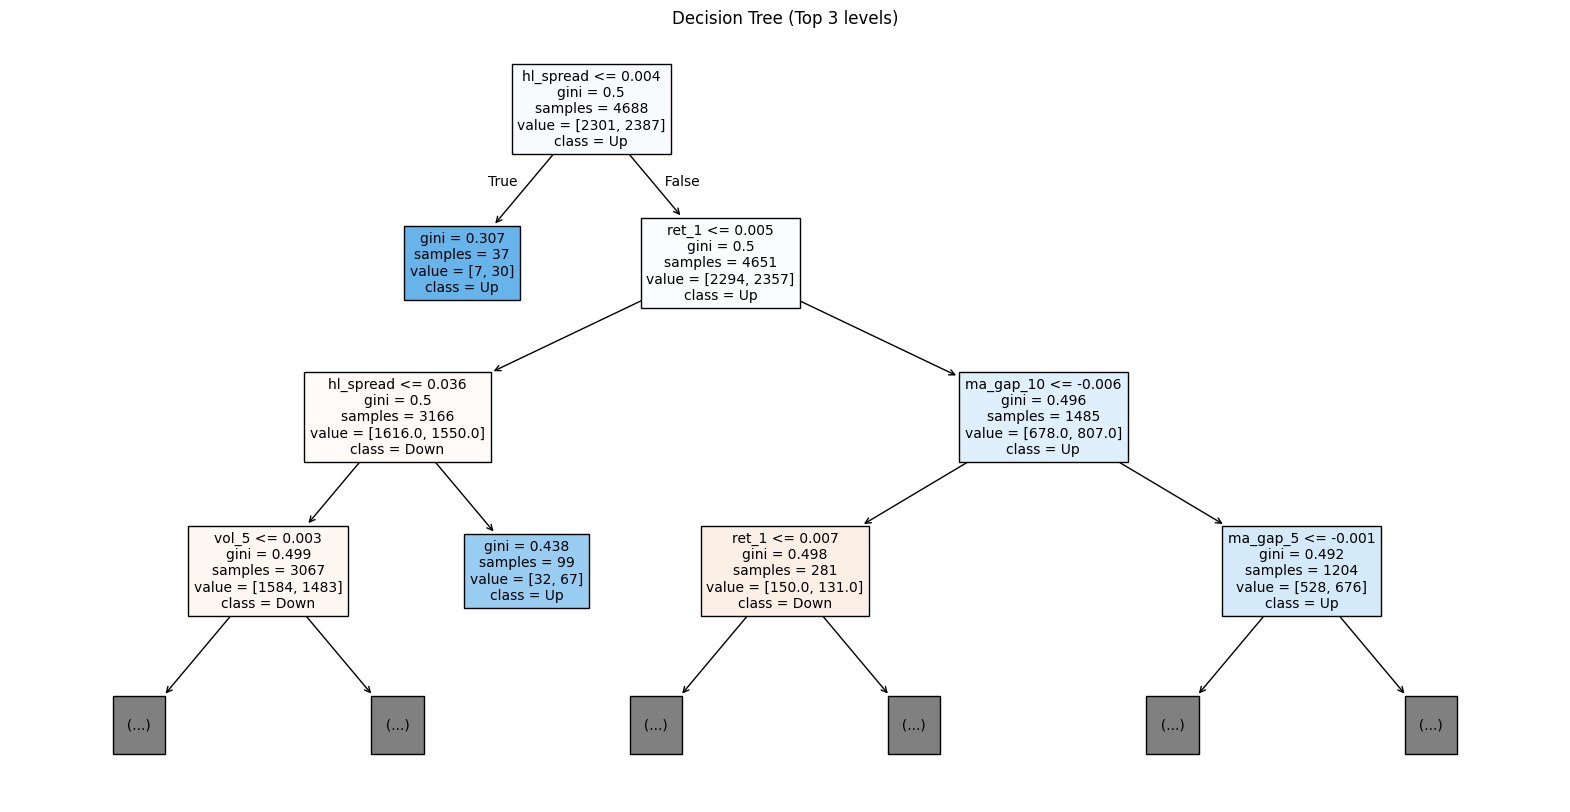

|--- hl_spread <= 0.00
|   |--- class: 1
|--- hl_spread >  0.00
|   |--- ret_1 <= 0.01
|   |   |--- hl_spread <= 0.04
|   |   |   |--- vol_5 <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- vol_5 >  0.00
|   |   |   |   |--- vol_5 <= 0.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- vol_5 >  0.01
|   |   |   |   |   |--- class: 0
|   |   |--- hl_spread >  0.04
|   |   |   |--- class: 1
|   |--- ret_1 >  0.01
|   |   |--- ma_gap_10 <= -0.01
|   |   |   |--- ret_1 <= 0.01
|   |   |   |   |--- class: 1
|   |   |   |--- ret_1 >  0.01
|   |   |   |   |--- ret_3 <= -0.04
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ret_3 >  -0.04
|   |   |   |   |   |--- class: 0
|   |   |--- ma_gap_10 >  -0.01
|   |   |   |--- ma_gap_5 <= -0.00
|   |   |   |   |--- class: 0
|   |   |   |--- ma_gap_5 >  -0.00
|   |   |   |   |--- ma_gap_10 <= 0.02
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ma_gap_10 >  0.02
|   |   |   |   |   |--- class: 1



In [3]:
# 3) 決策樹可視化（深度控制避免圖太大）
plt.figure(figsize=(20, 10))
plot_tree(
    best_clf,
    feature_names=features,
    class_names=["Down", "Up"],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Decision Tree (Top 3 levels)")
plt.show()

# 4) 文字版規則（適合放報告）
rules_text = export_text(best_clf, feature_names=features)
print(rules_text[:3000])  # 避免一次印太長

hl_spread    0.304127
ret_1        0.218944
ma_gap_10    0.173785
vol_5        0.164918
ma_gap_5     0.075796
ret_3        0.062430
ret_5        0.000000
oc_change    0.000000
dtype: float64


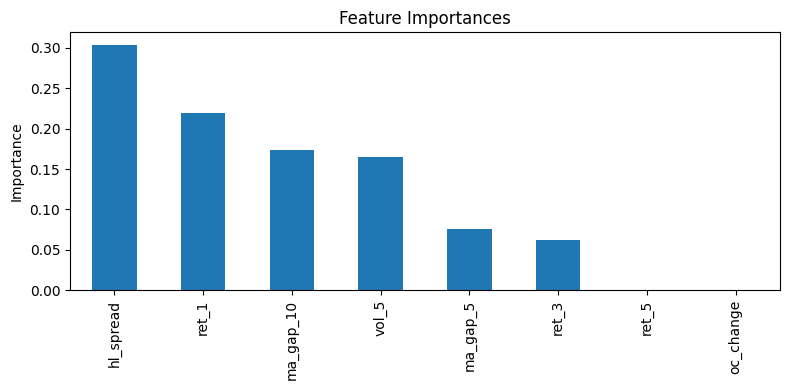

In [4]:
# 5) 特徵重要度
importances = pd.Series(best_clf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 4))
importances.plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

原始資料筆數: 104224

使用指數: TWII
可用資料筆數: 5869

清理後可建模筆數: 4515
Target 分布:
Target
1    0.537099
0    0.462901
Name: ratio, dtype: float64

Accuracy
0.5393

ROC-AUC
0.507

Classification Report
              precision    recall  f1-score   support

           0     0.4655    0.2005    0.2803       404
           1     0.5569    0.8136    0.6612       499

    accuracy                         0.5393       903
   macro avg     0.5112    0.5071    0.4708       903
weighted avg     0.5160    0.5393    0.4908       903


Confusion Matrix
[[ 81 323]
 [ 93 406]]

Feature Importance
        Feature  Importance
0  VolumeChange    0.380371
1        Return    0.314454
2    Volatility    0.305175
3           MA5    0.000000
4          MA10    0.000000
5         Trend    0.000000


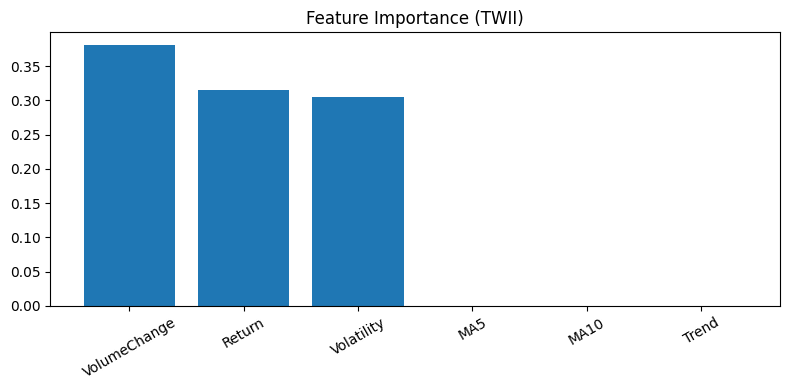

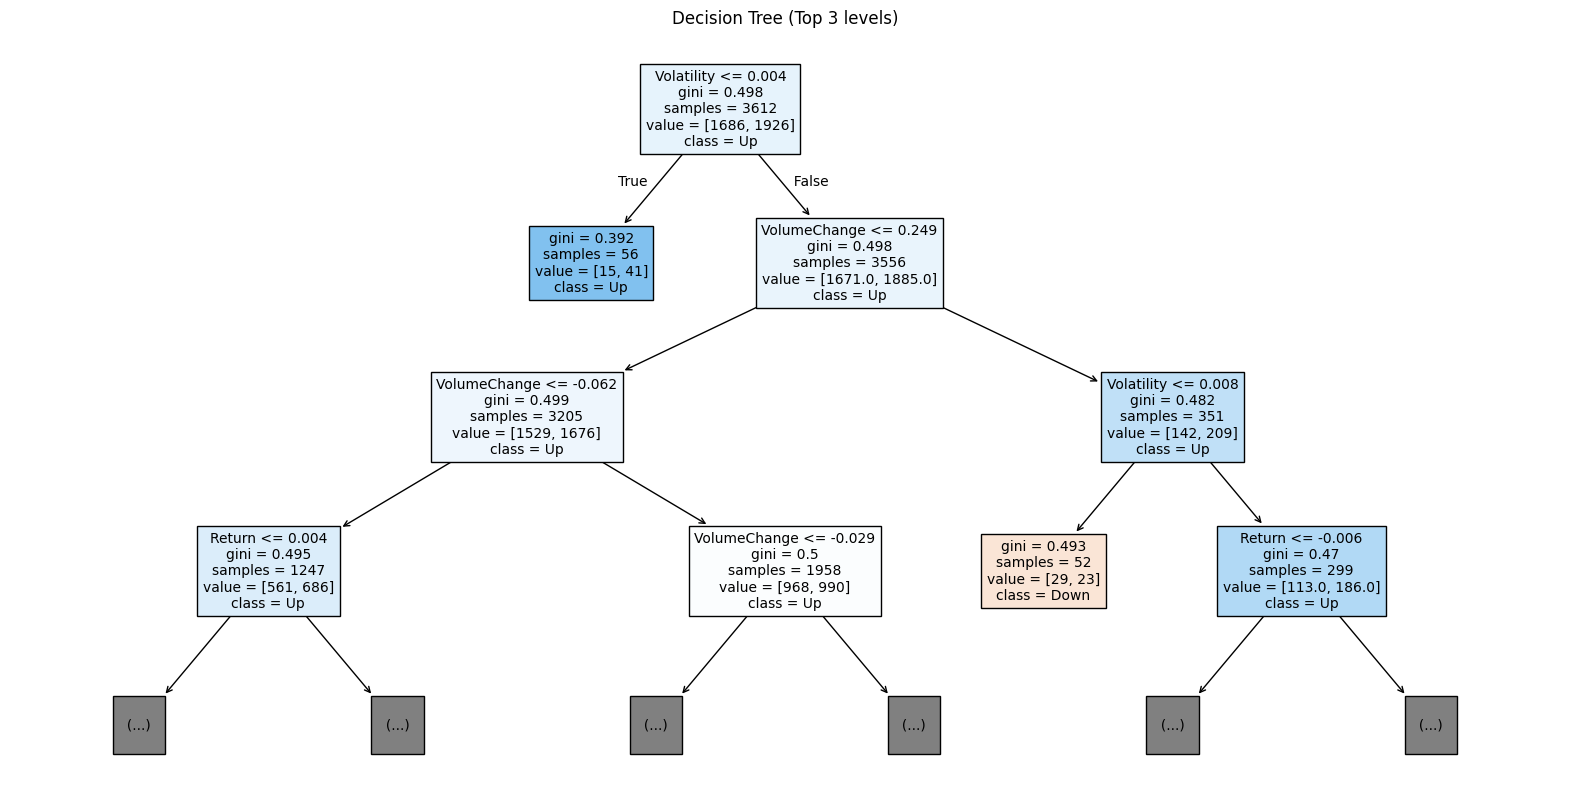


Prediction Result (Top 20)
             Date        Close    Return  Volatility  VolumeChange  \
103316 2017-09-01  10594.82031  0.001754    0.004795      0.114614   
103317 2017-09-04  10569.87012 -0.001471    0.005175     -0.160778   
103318 2017-09-05  10617.83984  0.003188    0.005046      0.053897   
103319 2017-09-06  10547.86035 -0.004343    0.008078      0.019775   
103320 2017-09-07  10538.50977 -0.002488    0.008930      0.146221   
103321 2017-09-08  10609.95020  0.005311    0.005583     -0.126762   
103322 2017-09-11  10572.16016 -0.005456    0.008557      0.056596   
103323 2017-09-12  10610.34961  0.000002    0.005680     -0.019109   
103324 2017-09-13  10532.87988 -0.005991    0.008301     -0.071658   
103325 2017-09-14  10553.57031  0.001859    0.006063     -0.081025   
103326 2017-09-15  10580.41016  0.002235    0.005730      0.350791   
103327 2017-09-18  10631.57031  0.003850    0.005699      0.062212   
103328 2017-09-19  10576.13965 -0.007247    0.009736     -0.14

In [7]:
# =========================================
# 利用 OHLCV + Decision Tree 預測明日漲跌（強化版）
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# =========================================
# 1. 讀取資料與基本設定
# =========================================

df = pd.read_csv("indexProcessed.csv")
target_index = "TWII"  # 可改成 HSI, NYA...

print("原始資料筆數:", len(df))

# 日期格式 + 排序（先按 Index，再按 Date）
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values(["Index", "Date"]).reset_index(drop=True)

# 只取單一指數建模，避免不同市場混在一起
d = df[df["Index"] == target_index].copy()
if d.empty:
    raise ValueError(f"找不到 Index={target_index} 的資料，請確認 indexProcessed.csv")

print(f"\n使用指數: {target_index}")
print("可用資料筆數:", len(d))

# =========================================
# 2. 建立 Feature Engineering
# =========================================

# 當日報酬
d["Return"] = (d["Close"] - d["Open"]) / d["Open"]

# 區間波動
d["Volatility"] = (d["High"] - d["Low"]) / d["Close"]

# 成交量變化（前一天量為 0 時可能產生 inf）
d["VolumeChange"] = d["Volume"].pct_change()

# 均線與趨勢
d["MA5"] = d["Close"].rolling(window=5).mean()
d["MA10"] = d["Close"].rolling(window=10).mean()
d["Trend"] = (d["MA5"] - d["MA10"]) / d["MA10"]

# =========================================
# 3. 建立 Label（明日漲跌）
# =========================================

d["Target"] = (d["Close"].shift(-1) > d["Close"]).astype(int)

# =========================================
# 4. 清理數值異常與缺失值
# =========================================

features = ["Return", "Volatility", "VolumeChange", "MA5", "MA10", "Trend"]

# 將 inf/-inf 轉為 NaN 再統一移除
d = d.replace([np.inf, -np.inf], np.nan)
model_df = d.dropna(subset=features + ["Target"]).copy()

if len(model_df) < 100:
    raise ValueError("可用資料太少，請更換指數或放寬特徵設定")

print("\n清理後可建模筆數:", len(model_df))
print("Target 分布:")
print(model_df["Target"].value_counts(normalize=True).rename("ratio"))

# =========================================
# 5. 切分訓練與測試資料（時間序列）
# =========================================

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

X_train = train_df[features]
X_test = test_df[features]
y_train = train_df["Target"]
y_test = test_df["Target"]

# =========================================
# 6. 建立與訓練模型
# =========================================

model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)
model.fit(X_train, y_train)

# =========================================
# 7. 預測與評估
# =========================================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n========================")
print("Accuracy")
print("========================")
print(round(accuracy, 4))

print("\n========================")
print("ROC-AUC")
print("========================")
print(round(auc, 4))

print("\n========================")
print("Classification Report")
print("========================")
print(classification_report(y_test, y_pred, digits=4))

print("\n========================")
print("Confusion Matrix")
print("========================")
print(confusion_matrix(y_test, y_pred))

# =========================================
# 8. Feature Importance
# =========================================

importance_df = (
    pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n========================")
print("Feature Importance")
print("========================")
print(importance_df)

# =========================================
# 9. 視覺化
# =========================================

plt.figure(figsize=(8, 4))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title(f"Feature Importance ({target_index})")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=features,
    class_names=["Down", "Up"],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Decision Tree (Top 3 levels)")
plt.show()

# =========================================
# 10. 查看部分預測結果
# =========================================

result_df = test_df[["Date", "Close"] + features].copy()
result_df["Actual"] = y_test.values
result_df["Predicted"] = y_pred
result_df["Prob_Up"] = y_proba

print("\n========================")
print("Prediction Result (Top 20)")
print("========================")
print(result_df.head(20))